In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import random

## Generates N random points for logistic regression on a line w
def generate_lr(N=20,w0=0,w1=1):
    n = 0
    X1 = []
    Y = []
    while(n < N):
        x1 = random.uniform(-10,10)
        x2 = random.uniform(-1,1)
        y = w0 + w1*x1 + x2
        X1.append(x1)
        Y.append(y)
        n += 1
    data = [np.array([1,X1[i],Y[i]]) for i in range(N)]
    return data

In [3]:
f_w0, f_w1 = 1, 1
N = 50
data = generate_lr(N, f_w0, f_w1)

In [4]:
def abline(slope, intercept, color='b'):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept), c=color )

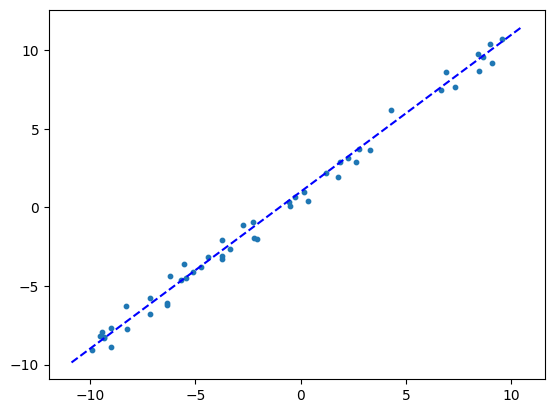

In [5]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
markers = [] #'o' or '+'
colors = [] # 'b' or 'r'
cnt = 0
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
plt.show()

In [6]:
X = [[i[0], i[1]] for i in data]
Y  = [i[2] for i in data]

In [7]:
XtX = np.matmul(np.transpose(X), X)
XtX.shape

(2, 2)

In [8]:
XtX_inv = np.linalg.inv(XtX)
XtX_inv.shape
XtX_inv

array([[0.0213312 , 0.0008691 ],
       [0.0008691 , 0.00056742]])

In [9]:
X_pi = np.matmul(XtX_inv, np.transpose(X))
X_pi

array([[ 0.02146772,  0.0292048 ,  0.01935626,  0.01414474,  0.02327405,
         0.02732823,  0.02083251,  0.01952773,  0.01651568,  0.01511068,
         0.01942301,  0.01687532,  0.01322873,  0.01352657,  0.0271223 ,
         0.02505831,  0.02288351,  0.02238836,  0.01661329,  0.01594089,
         0.02107972,  0.02915245,  0.02362164,  0.02375422,  0.02867437,
         0.01417156,  0.02883621,  0.01893594,  0.01510753,  0.01272927,
         0.01583975,  0.0229742 ,  0.01808189,  0.01350479,  0.02087537,
         0.02963269,  0.01641522,  0.02418542,  0.01305546,  0.01313984,
         0.02864409,  0.0180884 ,  0.02770731,  0.01723302,  0.01750865,
         0.02164336,  0.01324169,  0.01584035,  0.01807026,  0.01843265],
       [ 0.00095824,  0.00600957, -0.00042028, -0.00382275,  0.00213754,
         0.00478441,  0.00054352, -0.00030833, -0.00227482, -0.00319211,
        -0.0003767 , -0.00204002, -0.00442079, -0.00422634,  0.00464996,
         0.00330244,  0.00188257,  0.0015593 , -0.

In [10]:
w = np.matmul(X_pi, Y)
w

array([0.89687644, 0.9895128 ])

Plot the final hypothesis with the target and the data points

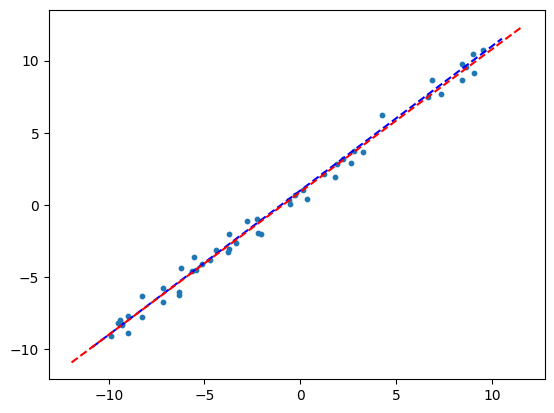

In [11]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
abline(w[1],w[0], color='r')
plt.show()

In [16]:
Y_pred = np.matmul(X, w)
np.sum(np.square(Y_pred-Y))

14.720670702942733

In [20]:
w_other = [3, 2]
Y_other = np.matmul(X, w_other)
np.sum(np.square(Y_other-Y))

1829.6793144444268

What about the test data set?

In [23]:
#50 test samples
testdata = generate_lr(50, f_w0, f_w1)
X_test = [[i[0], i[1]] for i in testdata]
Y_test  = [i[2] for i in testdata]
Y_pred_test = np.matmul(X_test, w)
np.sum(np.square(Y_pred_test-Y_test))

14.26072724344511

In [24]:
Y_pred_test_target = np.matmul(X_test, [1, 1])
np.sum(np.square(Y_pred_test_target-Y_test))

12.8044026526678